hello b17/00000/25


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
# Replace with your file name
df = pd.read_csv("Rainfall_data.csv")

df.head()
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(DAY=1))

df.head()

,Year,Month,Day,Specific Humidity,Relative Humidity,Temperature,Precipitation,Date
0,2000,1,1,8.06,48.25,23.93,0.00,2000-01-01
1,2000,2,1,8.73,50.81,25.83,0.11,2000-02-01
2,2000,3,1,8.48,42.88,26.68,0.01,2000-03-01
3,2000,4,1,13.79,55.69,22.49,0.02,2000-04-01
4,2000,5,1,17.40,70.88,19.07,271.14,2000-05-01


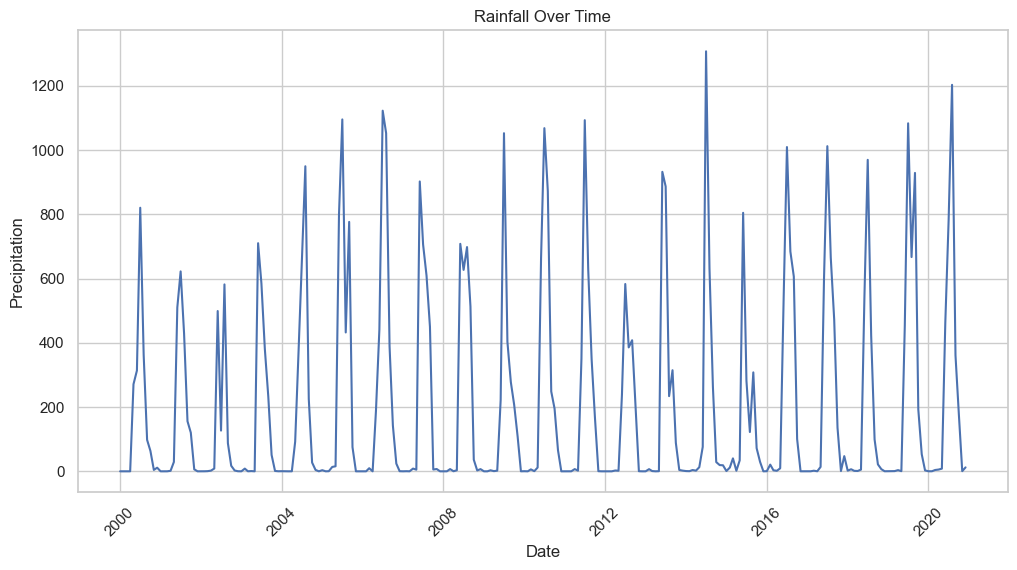

In [8]:
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Precipitation'])
plt.title("Rainfall Over Time")
plt.xlabel("Date")
plt.ylabel("Precipitation")
plt.xticks(rotation=45)
plt.show()

### Rainfall Over Time Analysis

- The highest rainfall occurred in ______.
- The rainfall shows (increasing/decreasing/seasonal) trends over time.

In [13]:
# Find row with highest rainfall
max_rain = df.loc[df['Precipitation'].idxmax()]

print("Highest Rainfall:")
print("Year:", max_rain['Year'])
print("Month:", max_rain['Month'])
print("Value:", max_rain['Precipitation'])

Highest Rainfall:
Year: 2014
Month: 7
Value: 1307.43


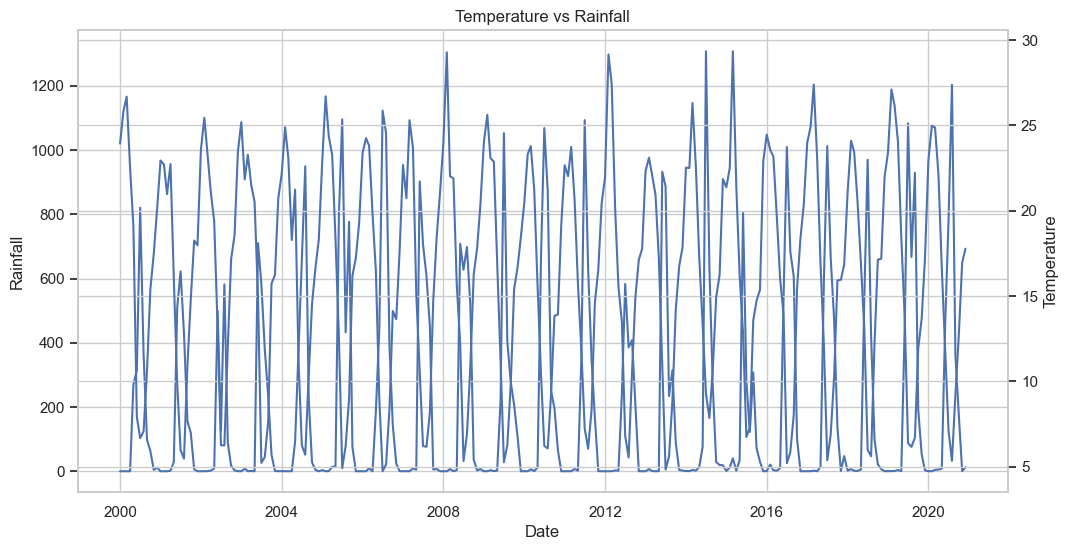

In [9]:
fig, ax1 = plt.subplots(figsize=(12,6))

ax1.set_xlabel("Date")
ax1.set_ylabel("Rainfall")
ax1.plot(df['Date'], df['Precipitation'])

ax2 = ax1.twinx()
ax2.set_ylabel("Temperature")
ax2.plot(df['Date'], df['Temperature'])

plt.title("Temperature vs Rainfall")
plt.show()

### Temperature vs Rainfall

- Rainfall increases when temperature is ______.
- There (are / are no) visible seasonal patterns.

In [14]:
# Check general trend using correlation with time index
df_sorted = df.sort_values('Date')
df_sorted['time_index'] = range(len(df_sorted))

trend = df_sorted['Precipitation'].corr(df_sorted['time_index'])

print("Trend correlation:", trend)

if trend > 0:
    print("Rainfall shows an increasing trend over time.")
elif trend < 0:
    print("Rainfall shows a decreasing trend over time.")
else:
    print("No clear trend over time.")

Trend correlation: 0.06516607051816828
Rainfall shows an increasing trend over time.


In [15]:
temp_rain_corr = df['Temperature'].corr(df['Precipitation'])

print("Temperature vs Rainfall Correlation:", temp_rain_corr)

if temp_rain_corr > 0:
    print("Rainfall tends to increase with higher temperature.")
elif temp_rain_corr < 0:
    print("Rainfall tends to increase with lower temperature.")
else:
    print("No clear relationship between temperature and rainfall.")

Temperature vs Rainfall Correlation: -0.779398786689349
Rainfall tends to increase with lower temperature.


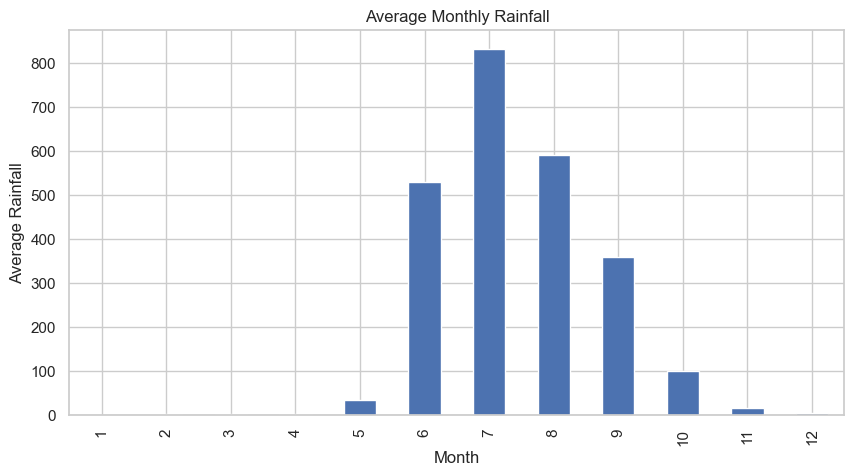

In [10]:
monthly_avg = df.groupby('Month')['Precipitation'].mean()

plt.figure(figsize=(10,5))
monthly_avg.plot(kind='bar')
plt.title("Average Monthly Rainfall")
plt.xlabel("Month")
plt.ylabel("Average Rainfall")
plt.show()

### Monthly Rainfall Analysis

- The wettest month is ______.
- The driest month is ______.
- This information can help in agriculture by ______.

In [16]:
monthly_avg = df.groupby('Month')['Precipitation'].mean()

print(monthly_avg)

# Check variation
variation = monthly_avg.std()

if variation > 0:
    print("There are seasonal patterns in rainfall.")
else:
    print("No strong seasonal pattern detected.")

Month
1       0.418095
2       2.663333
3       3.954286
4       2.526667
5      34.043333
6     530.559048
7     833.183810
8     591.337143
9     360.175238
10    101.537143
11     16.314762
12      4.874286
Name: Precipitation, dtype: float64
There are seasonal patterns in rainfall.


In [17]:
wettest_month = monthly_avg.idxmax()
driest_month = monthly_avg.idxmin()

print("Wettest Month:", wettest_month)
print("Driest Month:", driest_month)

Wettest Month: 7
Driest Month: 1


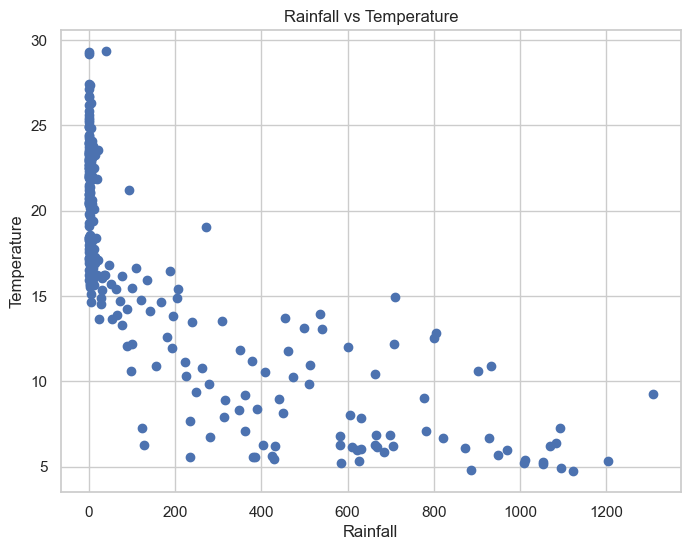

In [11]:
plt.figure(figsize=(8,6))
plt.scatter(df['Precipitation'], df['Temperature'])
plt.title("Rainfall vs Temperature")
plt.xlabel("Rainfall")
plt.ylabel("Temperature")
plt.show()

In [18]:
# Correlation
corr = df['Precipitation'].corr(df['Temperature'])
print("Correlation:", corr)

# Detect outliers using IQR
Q1 = df['Precipitation'].quantile(0.25)
Q3 = df['Precipitation'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['Precipitation'] < Q1 - 1.5 * IQR) | 
              (df['Precipitation'] > Q3 + 1.5 * IQR)]

print("Number of outliers:", len(outliers))

Correlation: -0.7793987866893489
Number of outliers: 17


In [12]:
correlation = df['Precipitation'].corr(df['Temperature'])
print("Correlation:", correlation)

Correlation: -0.7793987866893489


### Scatter Plot Analysis

- The correlation between rainfall and temperature is ______.
- There (is / is no) strong relationship.
- Outliers (are / are not) present.

### Final Interpretation

The data shows that rainfall varies across different months with clear seasonal patterns. The wettest months are ______ while the driest months are ______. The relationship between temperature and rainfall appears to be ______, indicating that temperature may influence rainfall patterns. These insights are useful for agriculture and water resource planning.